In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, NotRequired
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
from pprint import pprint

In [4]:
load_dotenv()

True

In [5]:
model = ChatGroq(model="llama-3.3-70b-versatile")

In [15]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: NotRequired[float]
    boundary_per_ball: NotRequired[float]
    boundary_pct: NotRequired[float]
    
    summary: NotRequired[str]

In [17]:
def calculate_sr(state: BatsmanState) -> dict:
    sr = ((state.get('runs'))/(state.get('balls')))*100
    return {'sr': sr}

In [18]:
def calculate_bpb(state: BatsmanState) -> dict:
    bpb = state.get('balls')/(state.get('fours') + state.get('sixes'))
    return {"boundary_per_ball": bpb}

In [19]:
def calculate_boundary_pct(state: BatsmanState) -> dict:
    boundary_pct = (((state.get('fours') * 4) + (state.get('sixes') * 6))/state.get('runs'))*100
    return {"boundary_pct": boundary_pct}

In [25]:
def summary(state: BatsmanState) -> dict:
    summary = f"""
        Strike Rate: {state.get('sr')} \n
        Boundary per ball: {state.get('boundary_per_ball')} \n
        Boundary PCT: {state.get('boundary_pct')}
    """
    return {"summary": summary}

In [26]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_pct', calculate_boundary_pct)
graph.add_node('summary', summary)

graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_pct')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_pct', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()

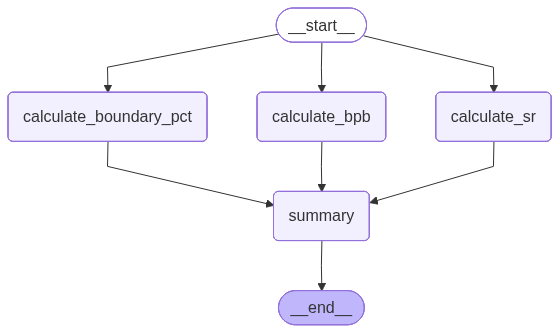

In [27]:
workflow

In [28]:
initial_state: BatsmanState = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

final_state = workflow.invoke(initial_state)

In [29]:
final_state

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'boundary_per_ball': 5.0,
 'boundary_pct': 48.0,
 'summary': '\n        Strike Rate: 200.0 \n\n        Boundary per ball: 5.0 \n\n        Boundary PCT: 48.0\n    '}